# Sales Data Analysis
 
## Problem Statement
Analyze 9,994 sales transactions from a US-based superstore
to identify monthly revenue trends, top-performing products,
regional performance gaps, and profit drivers.
 
## Dataset
- Source: Kaggle Superstore Sales Dataset
- Rows: 9,994  Columns: 21
- Period: 2014-2017
 
## Tools
Python | Pandas | Matplotlib | Seaborn | Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
 
print('All libraries imported successfully')

All libraries imported successfully


In [4]:
df = pd.read_csv("C:/Users/BHANUPRAKASH\OneDrive/Desktop/DA Projects/Sales Data Analysis/data/raw/Sample - Superstore.csv", encoding='latin-1')
 
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [5]:
print('=== Dataset Info ===')
df.info()
 
print('\n=== Missing Values ===')
print(df.isnull().sum())
 
print('\n=== Basic Stats ===')
df[['Sales','Profit','Discount','Quantity']].describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

,Sales,Profit,Discount,Quantity
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16,3.79
std,623.25,234.26,0.21,2.23
min,0.44,-6599.98,0.00,1.00
25%,17.28,1.73,0.00,2.00
50%,54.49,8.67,0.20,3.00
75%,209.94,29.36,0.20,5.00
max,22638.48,8399.98,0.80,14.00


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
 
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows')
 
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['Quarter']     = df['Order Date'].dt.quarter
df['MonthPeriod'] = df['Order Date'].dt.to_period('M')
 
df.to_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/data/cleaned/sales_cleaned.csv', index=False)
print(f'Cleaned dataset saved: {len(df)} rows')
df.head(2)

Removed 0 duplicate rows
Cleaned dataset saved: 9994 rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,MonthPeriod
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,11,4,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,11,4,2016-11


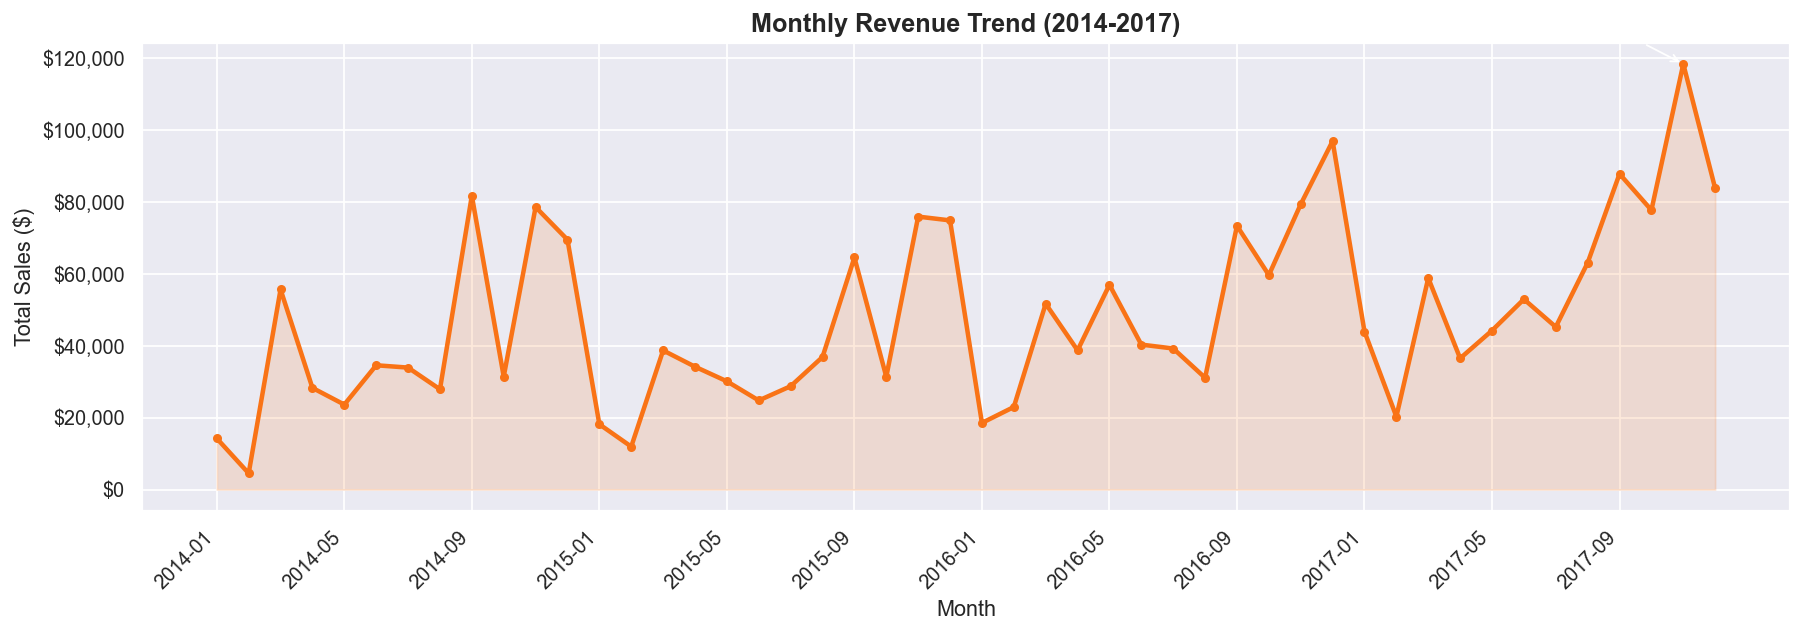

KEY FINDING: Peak revenue month = 2017-11 ($118,448)


In [12]:
monthly = df.groupby('MonthPeriod')['Sales'].sum().reset_index()
monthly['MonthPeriod'] = monthly['MonthPeriod'].astype(str)
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['MonthPeriod'], monthly['Sales'],
        color='#F97316', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(range(len(monthly)), monthly['Sales'],
                alpha=0.15, color='#F97316')
 
max_idx = monthly['Sales'].idxmax()
ax.annotate(f"Peak: ${monthly['Sales'][max_idx]:,.0f}",
            xy=(max_idx, monthly['Sales'][max_idx]),
            xytext=(max_idx-4, monthly['Sales'][max_idx]+8000),
            arrowprops=dict(arrowstyle='->', color='white'),
            color='white', fontsize=10)
 
ax.set_title('Monthly Revenue Trend (2014-2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
step = max(1, len(monthly)//12)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['MonthPeriod'][::step], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/visuals/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
 
peak = monthly.loc[max_idx]
print(f'KEY FINDING: Peak revenue month = {peak["MonthPeriod"]} (${peak["Sales"]:,.0f})')

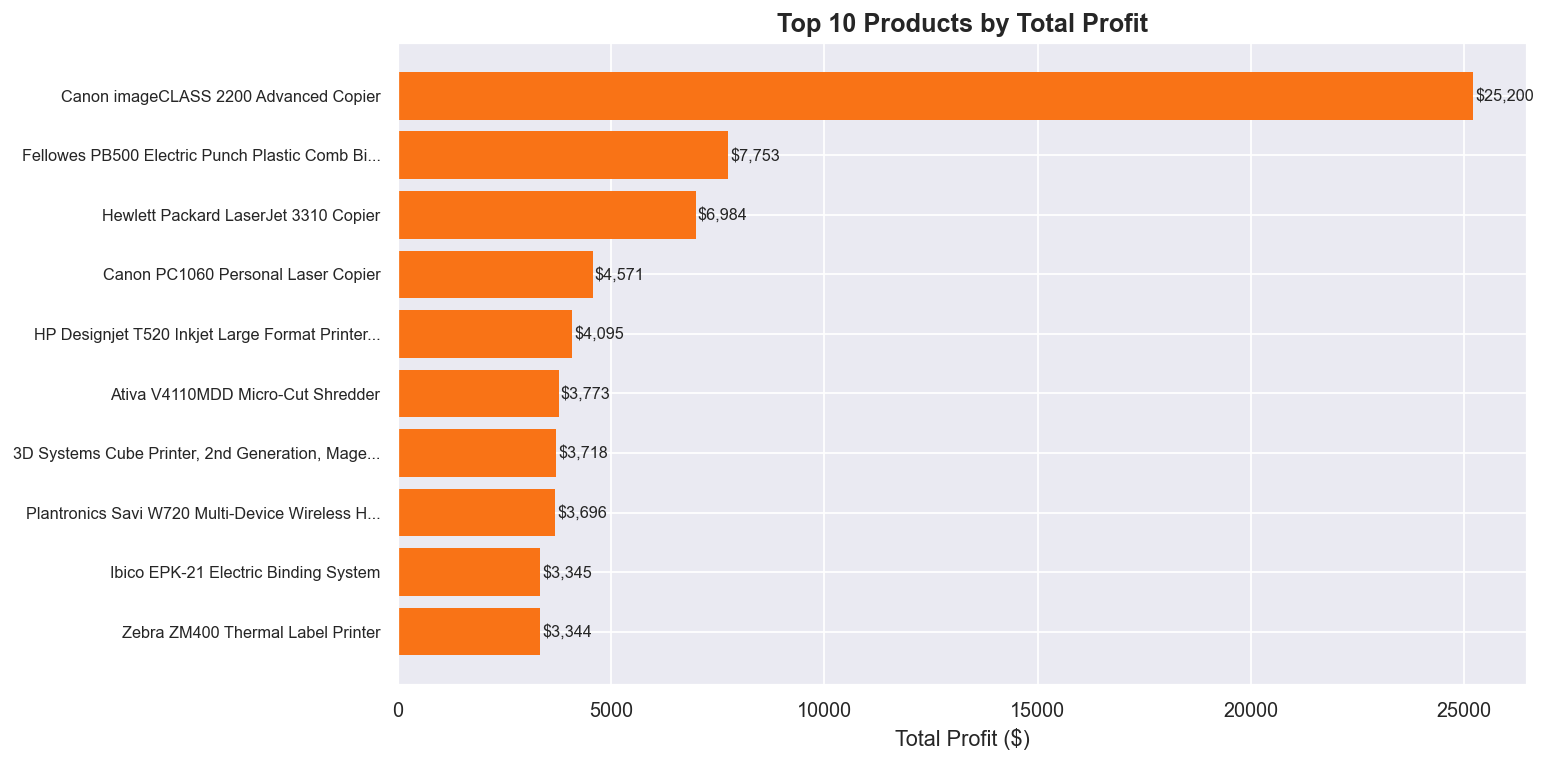

KEY FINDING: Top product = Canon imageCLASS 2200 Advanced Copier
KEY FINDING: Top product profit = $25,200


In [14]:
top_prod = (df.groupby('Product Name')['Profit']
            .sum().sort_values(ascending=False).head(10))
 
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_prod)), top_prod.values,
               color='#F97316', edgecolor='none')
ax.set_yticks(range(len(top_prod)))
ax.set_yticklabels([n[:45]+'...' if len(n)>45 else n
                    for n in top_prod.index], fontsize=9)
ax.invert_yaxis()
for bar, val in zip(bars, top_prod.values):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
 
ax.set_title('Top 10 Products by Total Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/visuals/top10_products_profit.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f'KEY FINDING: Top product = {top_prod.index[0]}')
print(f'KEY FINDING: Top product profit = ${top_prod.iloc[0]:,.0f}')

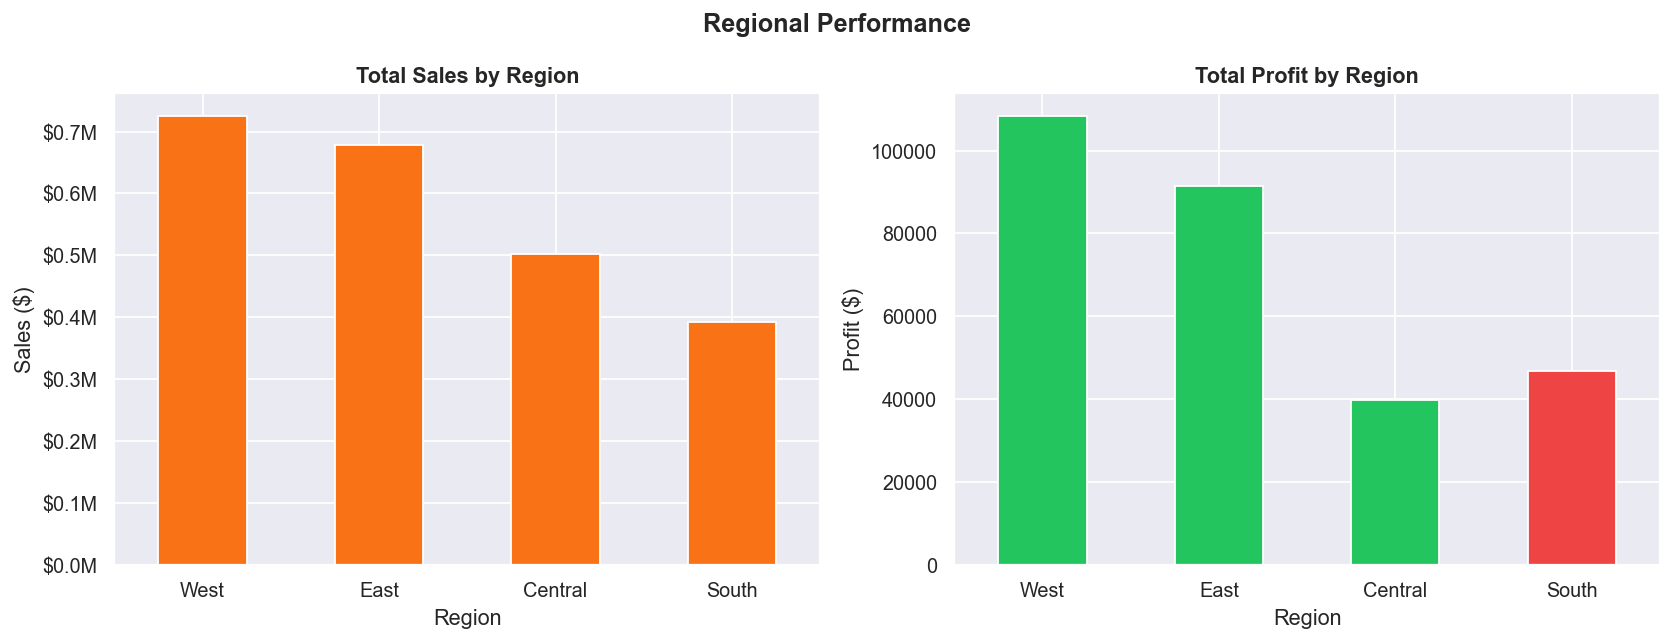

KEY FINDING: Best sales region  = West
KEY FINDING: Worst profit region = Central


In [15]:
region = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
region['Sales'].plot(kind='bar', ax=axes[0], color='#F97316', rot=0)
axes[0].set_title('Total Sales by Region', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
 
region['Profit'].plot(kind='bar', ax=axes[1], rot=0,
    color=['#22c55e','#22c55e','#22c55e','#ef4444'])
axes[1].set_title('Total Profit by Region', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
 
plt.suptitle('Regional Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/visuals/regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f'KEY FINDING: Best sales region  = {region["Sales"].idxmax()}')
print(f'KEY FINDING: Worst profit region = {region["Profit"].idxmin()}')

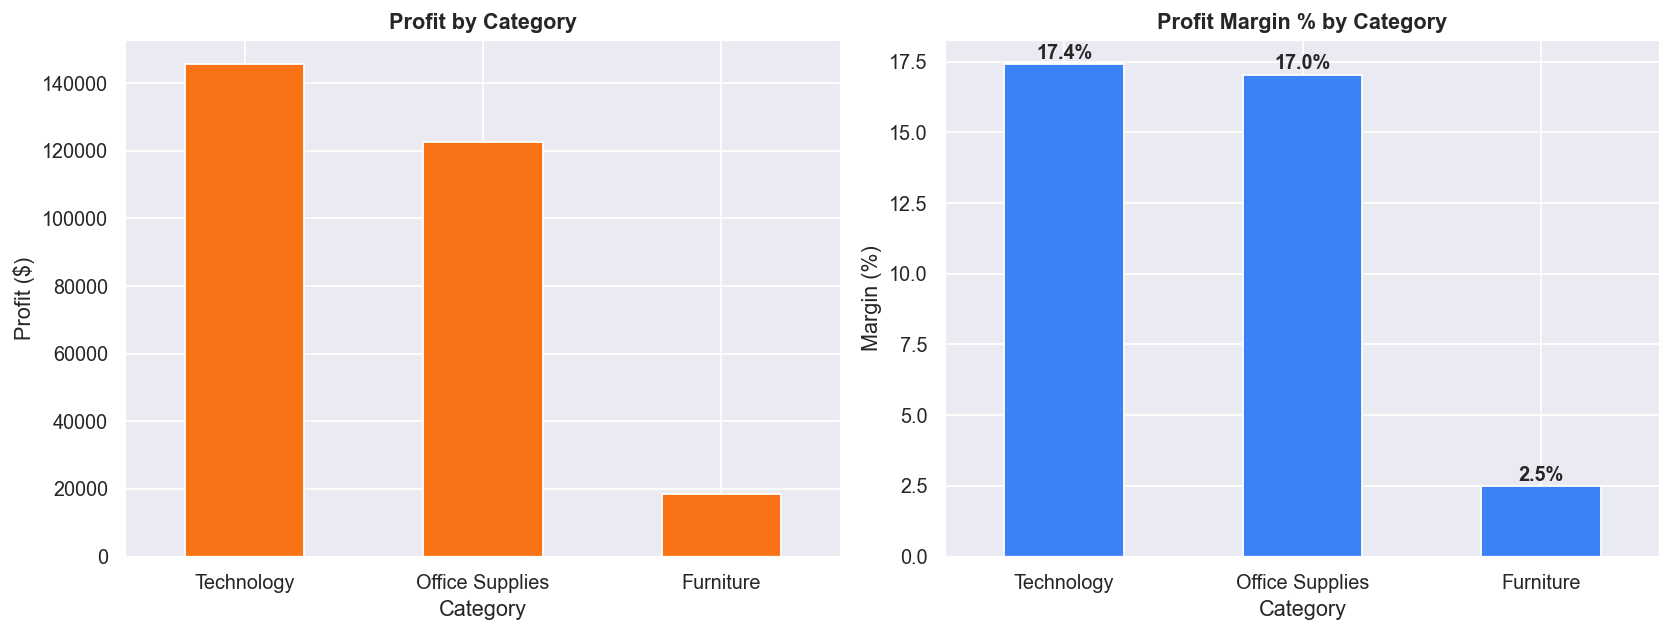

KEY FINDINGS - Category Profit:
  Technology: $145,455  (50.8% of total profit)
  Office Supplies: $122,491  (42.8% of total profit)
  Furniture: $18,451  (6.4% of total profit)


In [16]:
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
cat_sales  = df.groupby('Category')['Sales'].sum()
margin     = (cat_profit / cat_sales * 100).sort_values(ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_profit.plot(kind='bar', ax=axes[0], color='#F97316', rot=0)
axes[0].set_title('Profit by Category', fontweight='bold')
axes[0].set_ylabel('Profit ($)')
 
margin.plot(kind='bar', ax=axes[1], color='#3b82f6', rot=0)
axes[1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
for bar, val in zip(axes[1].patches, margin.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
 
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/visuals/category_profit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDINGS - Category Profit:')
for cat, val in cat_profit.items():
    pct = val / cat_profit.sum() * 100
    print(f'  {cat}: ${val:,.0f}  ({pct:.1f}% of total profit)')

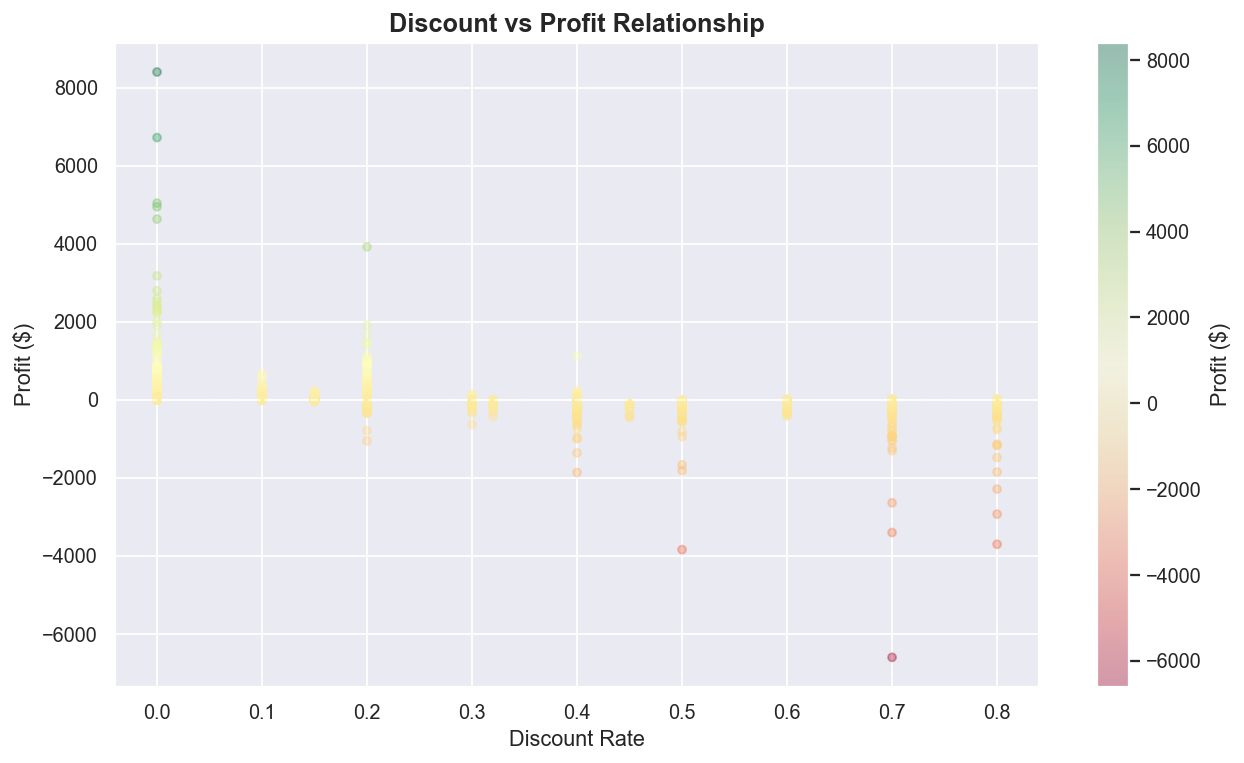

KEY FINDING: Discount-Profit correlation = -0.219
KEY FINDING: Avg profit with 0% discount    = $66.90
KEY FINDING: Avg profit with 40%+ discount  = $-107.65


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Discount'], df['Profit'],
                     alpha=0.35, c=df['Profit'],
                     cmap='RdYlGn', s=20)
plt.colorbar(scatter, label='Profit ($)')
ax.axhline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_title('Discount vs Profit Relationship', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Sales Data Analysis/visuals/discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
 
corr          = df['Discount'].corr(df['Profit'])
high_discount = df[df['Discount'] >= 0.4]['Profit'].mean()
no_discount   = df[df['Discount'] == 0.0]['Profit'].mean()
 
print(f'KEY FINDING: Discount-Profit correlation = {corr:.3f}')
print(f'KEY FINDING: Avg profit with 0% discount    = ${no_discount:.2f}')
print(f'KEY FINDING: Avg profit with 40%+ discount  = ${high_discount:.2f}')

# Key Findings - Sales Data Analysis
 
## Summary
 
| # | Finding | Your Value |
| 1 | Peak revenue month | 2017-11 ($118,448) |
| 2 | Top product by profit | Canon imageCLASS 2200 Advanced Copier |
| 3 | Best performing region | West |
| 4 | Technology profit share | $145,455  (50.8% of total profit) |
| 5 | Discount-profit correlation | -0.219 |
 
## Business Recommendations
1. Stock up on Technology products before Q4 peak season
2. Reduce discounts above 30% - they destroy profit margins
3. Investigate why Central region underperforms on profit
 
## Files Generated
- visuals/monthly_revenue_trend.png
- visuals/top10_products_profit.png
- visuals/regional_performance.png
- visuals/category_profit_analysis.png
- visuals/discount_vs_profit.png
- data/cleaned/sales_cleaned.csv